# Семинар 6: Домашнее задание - подсчет количества пальцев

**Это оцениваемое ДЗ**

Вам предлагается реализовать алгоритм, подсчитывающий количество пальцев.

Один из возможных вариантов решения:
- Получить бинаризованное изображение и найти контур руки;
- Построить выпуклый контур функцией `cv2.convexHull` - https://docs.opencv.org/3.4/d7/d1d/tutorial_hull.html
- Найти дефекты выпуклости контура функцией [`cv2.convexityDefects`](https://docs.opencv.org/3.4/d3/dc0/group__imgproc__shape.html#gada4437098113fd8683c932e0567f47ba)
- После некоторой фильтрации дефектов, их число будет напрямую коррелировать с числом пальцев.

**Требования:**
1. Продемонстрируйте работоспособность алгоритма на любом числе пальцев (от 0 до 5).
2. Используйте фото своей руки для демонстрации (предложенное фото лишь для отладки).

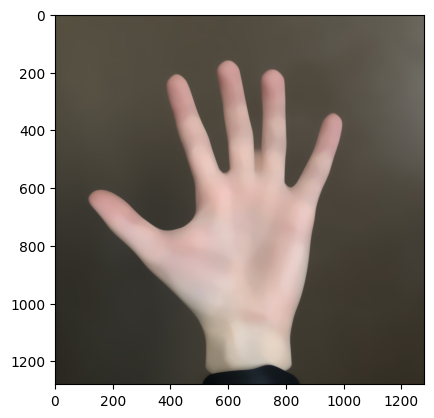

In [600]:
import cv2
from matplotlib import pyplot as plt
import numpy as np

img = cv2.cvtColor(cv2.imread("data/hand.jpg"), cv2.COLOR_BGR2RGB)
#img = cv2.bilateralFilter(img, 25, 75, 75)
img = cv2.medianBlur(img, 49)
plt.imshow(img);

In [601]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
_, bw = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY)

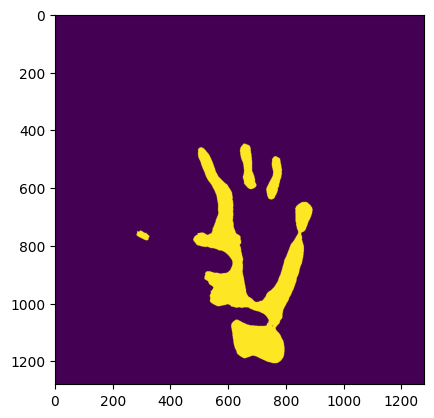

In [602]:
plt.imshow(bw);

In [603]:
kernel = np.array(
    [[  1,  1,  1],
     [  1, -8,  1],
     [  1,  1,  1]], dtype=np.float32)
# img_sobel = cv2.Sobel(gray, cv2.CV_32F, 1, 1)

imgLaplacian = cv2.filter2D(img, cv2.CV_32F, kernel)
imgLaplacian = cv2.cvtColor(imgLaplacian, cv2.COLOR_BGR2GRAY)
sharp = np.float32(gray)
imgResult = sharp - imgLaplacian

# convert back to 8bits gray scale
imgResult = np.clip(imgResult, 0, 255)
imgResult = imgResult.astype('uint8')
imgLaplacian = np.clip(imgLaplacian, 0, 255)
imgLaplacian = np.uint8(imgLaplacian)
imgLaplacian = cv2.dilate(imgLaplacian, np.ones((3,3), dtype=np.uint8), iterations=3)
imgLaplacian = (imgLaplacian > 5).astype('uint8')

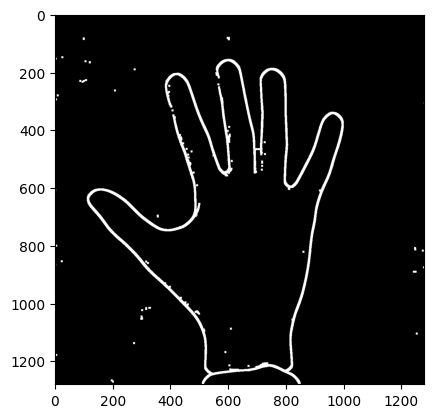

In [604]:
plt.imshow(imgLaplacian, cmap="Greys_r");

In [605]:
#edges = cv2.Canny(imgLaplacian,0,1)
#edges = cv2.erode(imgLaplacian, np.ones((5,5), dtype=np.uint8), iterations=1)
edges = cv2.dilate(imgLaplacian, np.ones((5,5), dtype=np.uint8), iterations=5)

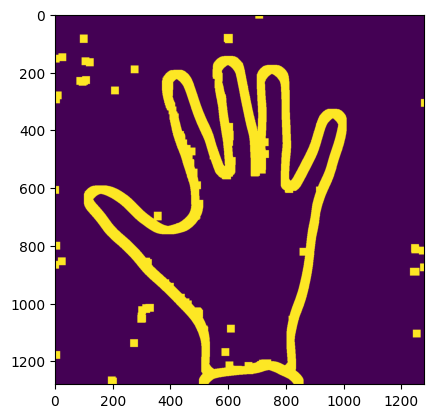

In [606]:
plt.imshow(edges)

In [607]:
num_labels, label_map = cv2.connectedComponents((edges == 0).astype('uint8'))


In [608]:
idx = np.argmax(gray)
x = idx // gray.shape[1]
y = idx % gray.shape[1]

In [609]:
num_labels

4

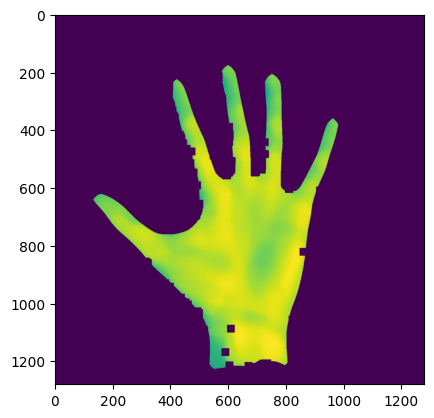

In [610]:
hand_map = label_map == label_map[x, y]
#hand_map = cv2.erode(hand_map.astype('uint8'), np.ones((5,5), dtype=np.uint8), iterations=5)
plt.imshow(gray * hand_map)

In [611]:
min_x = np.where(hand_map)[0].min()
max_x = np.where(hand_map)[0].max()
min_y = np.where(hand_map)[1].min()
max_y = np.where(hand_map)[1].max()
hand_crop = hand_map[min_x:max_x, min_y:max_y].copy()
h = 128
w = int(hand_crop.shape[1] * (h / hand_crop.shape[0]))
hand_map_small = cv2.resize(hand_crop.astype(np.uint8), (w, h))
hand_map_small = cv2.dilate(hand_map_small, np.ones((3,3), dtype=np.uint8), iterations=1)
#hand_map_small = cv2.erode(hand_map_small, np.ones((3,3), dtype=np.uint8), iterations=1)

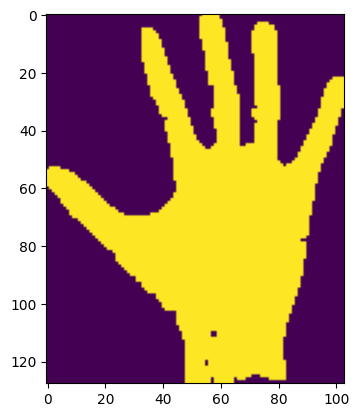

In [612]:
plt.imshow(hand_map_small)

In [613]:
from tqdm import tqdm
radius = 5
joint_map = np.zeros_like(hand_map_small, dtype=np.uint8)
for i in tqdm(range(hand_map_small.shape[0])):
    for j in range(hand_map_small.shape[1]):
       hand_map_del = hand_map_small.copy()
       hand_map_del[max(0, i-radius):min(hand_map_small.shape[0], i+radius), max(0, j-radius):min(hand_map_small.shape[1], j+radius)] = 0
       n_components, _ = cv2.connectedComponents(hand_map_del)
       if n_components > 2:
            joint_map[i, j] = 1


100%|██████████| 128/128 [00:01<00:00, 71.36it/s]


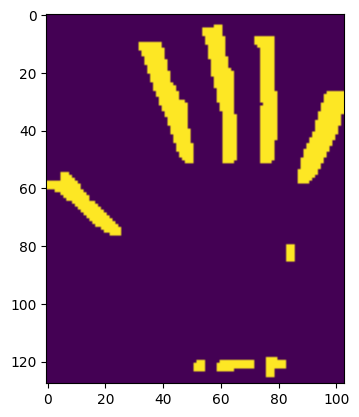

In [614]:
#cv2.erode(joint_map, np.ones((3,3), dtype=np.uint8), iterations=2, dst=joint_map)
cv2.dilate(joint_map, np.ones((3,3), dtype=np.uint8), iterations=1, dst=joint_map)
plt.imshow(joint_map)

In [615]:
num_components, components = cv2.connectedComponents(joint_map)
counts = np.bincount(components.flatten())
print("Number of fingers:", np.sum(counts[1:] > 60))

Number of fingers: 5


In [616]:
def get_fingers(img, vervbose=False):
    if isinstance(img, str):
        img = cv2.cvtColor(cv2.imread(img), cv2.COLOR_BGR2RGB)
    blur = cv2.medianBlur(img, 49)
    gray = cv2.cvtColor(blur, cv2.COLOR_RGB2GRAY)
    kernel = np.array(
        [[  1,  1,  1],
        [  1, -8,  1],
        [  1,  1,  1]], dtype=np.float32)

    imgLaplacian = cv2.filter2D(blur, cv2.CV_32F, kernel)
    imgLaplacian = cv2.cvtColor(imgLaplacian, cv2.COLOR_BGR2GRAY)
    sharp = np.float32(gray)
    imgResult = sharp - imgLaplacian

    # convert back to 8bits gray scale
    imgResult = np.clip(imgResult, 0, 255)
    imgResult = imgResult.astype('uint8')
    imgLaplacian = np.clip(imgLaplacian, 0, 255)
    imgLaplacian = np.uint8(imgLaplacian)
    imgLaplacian = cv2.dilate(imgLaplacian, np.ones((3,3), dtype=np.uint8), iterations=3)
    imgLaplacian = (imgLaplacian > 5).astype('uint8')
    
    edges = cv2.dilate(imgLaplacian, np.ones((5,5), dtype=np.uint8), iterations=5)

    idx = np.argmax(gray)
    x = idx // gray.shape[1]
    y = idx % gray.shape[1]
    
    num_labels, label_map = cv2.connectedComponents((edges == 0).astype('uint8'))
    hand_map = label_map == label_map[x, y]

    min_x = np.where(hand_map)[0].min()
    max_x = np.where(hand_map)[0].max()
    min_y = np.where(hand_map)[1].min()
    max_y = np.where(hand_map)[1].max()
    hand_crop = hand_map[min_x:max_x, min_y:max_y].copy()
    h = 128
    w = int(hand_crop.shape[1] * (h / hand_crop.shape[0]))
    hand_map_small = cv2.resize(hand_crop.astype(np.uint8), (w, h))
    hand_map_small = cv2.dilate(hand_map_small, np.ones((3,3), dtype=np.uint8), iterations=1)

    radius = 5
    joint_map = np.zeros_like(hand_map_small, dtype=np.uint8)
    for i in tqdm(range(hand_map_small.shape[0])):
        for j in range(hand_map_small.shape[1]):
            hand_map_del = hand_map_small.copy()
            hand_map_del[max(0, i-radius):min(hand_map_small.shape[0], i+radius), max(0, j-radius):min(hand_map_small.shape[1], j+radius)] = 0
            n_components, _ = cv2.connectedComponents(hand_map_del)
            if n_components > 2:
                    joint_map[i, j] = 1

    cv2.dilate(joint_map, np.ones((3,3), dtype=np.uint8), iterations=1, dst=joint_map)
    num_components, components = cv2.connectedComponents(joint_map)
    counts = np.bincount(components.flatten())
    num_fingers = np.sum(counts[1:] > 60)

    if vervbose:
        plt.imshow(img)
        plt.axis('off')
        print("Number of fingers:", num_fingers)

    return num_fingers

100%|██████████| 128/128 [00:01<00:00, 71.17it/s]


Number of fingers: 5


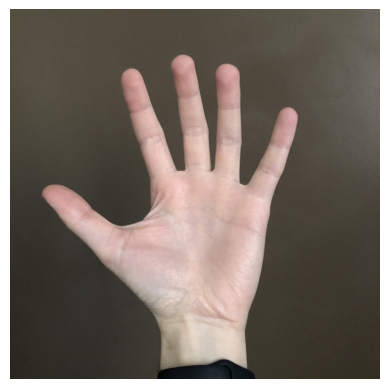

In [617]:
num_fingers = get_fingers("data/hand.jpg", vervbose=True)

100%|██████████| 128/128 [00:00<00:00, 178.34it/s]


Number of fingers: 1


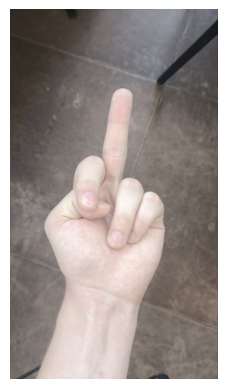

In [618]:
num_fingers = get_fingers("data/hand_1.jpg", vervbose=True)

100%|██████████| 128/128 [00:00<00:00, 157.88it/s]


Number of fingers: 2


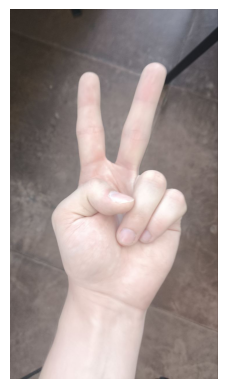

In [619]:
num_fingers = get_fingers("data/hand_2.jpg", vervbose=True)

100%|██████████| 128/128 [00:01<00:00, 89.93it/s]


Number of fingers: 3


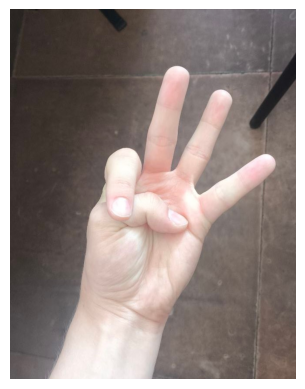

In [620]:
num_fingers = get_fingers("data/hand_3.jpg", vervbose=True)

100%|██████████| 128/128 [00:01<00:00, 99.76it/s]


Number of fingers: 4


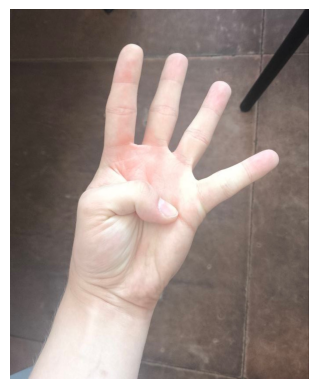

In [623]:
num_fingers = get_fingers("data/hand_4.jpg", vervbose=True)

100%|██████████| 128/128 [00:01<00:00, 80.73it/s]


Number of fingers: 5


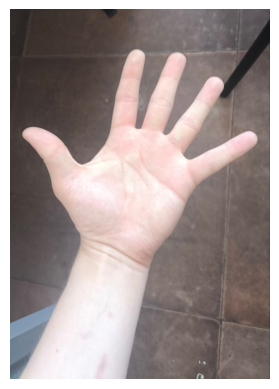

In [622]:
num_fingers = get_fingers("data/hand_5.jpg", vervbose=True)